In [2]:
import pandas as pd
import io
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

col_names = [
    "status", "duration", "credit_history", "purpose", "amount",
    "savings", "employment_duration", "installment_rate", "personal_status_sex",
    "other_debtors", "present_residence", "property", "age",
    "other_installment_plans", "housing", "number_credits", "job",
    "people_liable", "telephone", "foreign_worker", "credit_risk"
]

df = pd.read_csv(url, sep=" ", header=None, names=col_names)

print("Shape:", df.shape)
print("\nTarget value counts:")
print(df["credit_risk"].value_counts())
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 21)

Target value counts:
credit_risk
1    700
2    300
Name: count, dtype: int64

Column names:
['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

First 5 rows:


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [4]:
df.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [5]:
# Decode Statlog categorical columns
status_map = {
    'A11': '< 0 DM', 'A12': '0–200 DM', 'A13': '>= 200 DM', 'A14': 'no account'
}
credit_history_map = {
    'A30': 'no credits', 'A31': 'all paid', 'A32': 'existing paid',
    'A33': 'delay in past', 'A34': 'critical account'
}
purpose_map = {
    'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture', 'A43': 'TV/radio',
    'A44': 'appliances', 'A45': 'repairs', 'A46': 'education', 'A47': 'vacation',
    'A48': 'retraining', 'A49': 'business', 'A410': 'other'
}
savings_map = {
    'A61': '< 100 DM', 'A62': '100–500 DM', 'A63': '500–1000 DM',
    'A64': '>= 1000 DM', 'A65': 'unknown/none'
}
employment_map = {
    'A71': 'unemployed', 'A72': '< 1 yr', 'A73': '1–4 yrs',
    'A74': '4–7 yrs', 'A75': '>= 7 yrs'
}
personal_status_map = {
    'A91': 'male divorced', 'A92': 'female divorced/married',
    'A93': 'male single', 'A94': 'male married', 'A95': 'female single'
}
other_debtors_map = {'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'}
property_map = {
    'A121': 'real estate', 'A122': 'savings/insurance',
    'A123': 'car/other', 'A124': 'unknown/none'
}
other_installment_map = {'A141': 'bank', 'A142': 'stores', 'A143': 'none'}
housing_map = {'A151': 'rent', 'A152': 'own', 'A153': 'free'}
job_map = {
    'A171': 'unskilled non-resident', 'A172': 'unskilled resident',
    'A173': 'skilled', 'A174': 'highly skilled'
}
telephone_map = {'A191': 'none', 'A192': 'yes'}
foreign_worker_map = {'A201': 'yes', 'A202': 'no'}

df_decoded = df.copy()
df_decoded['status'] = df['status'].map(status_map)
df_decoded['credit_history'] = df['credit_history'].map(credit_history_map)
df_decoded['purpose'] = df['purpose'].map(purpose_map)
df_decoded['savings'] = df['savings'].map(savings_map)
df_decoded['employment_duration'] = df['employment_duration'].map(employment_map)
df_decoded['personal_status_sex'] = df['personal_status_sex'].map(personal_status_map)
df_decoded['other_debtors'] = df['other_debtors'].map(other_debtors_map)
df_decoded['property'] = df['property'].map(property_map)
df_decoded['other_installment_plans'] = df['other_installment_plans'].map(other_installment_map)
df_decoded['housing'] = df['housing'].map(housing_map)
df_decoded['job'] = df['job'].map(job_map)
df_decoded['telephone'] = df['telephone'].map(telephone_map)
df_decoded['foreign_worker'] = df['foreign_worker'].map(foreign_worker_map)

# Make target binary: 0 = good, 1 = bad
df_decoded['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

df_decoded.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account,TV/radio,1169,unknown/none,>= 7 yrs,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,0
1,0–200 DM,48,existing paid,TV/radio,5951,< 100 DM,1–4 yrs,2,female divorced/married,none,...,real estate,22,none,own,1,skilled,1,none,yes,1
2,no account,12,critical account,education,2096,< 100 DM,4–7 yrs,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing paid,furniture,7882,< 100 DM,4–7 yrs,2,male single,guarantor,...,savings/insurance,45,none,free,1,skilled,2,none,yes,0
4,< 0 DM,24,delay in past,car (new),4870,< 100 DM,1–4 yrs,3,male single,none,...,unknown/none,53,none,free,2,skilled,2,none,yes,1


/var/folders/_2/4xkg4dyd1zd06jf_5_zjz98h0000gn/T/ipykernel_24017/284418281.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Good (0)', 'Bad (1)'])


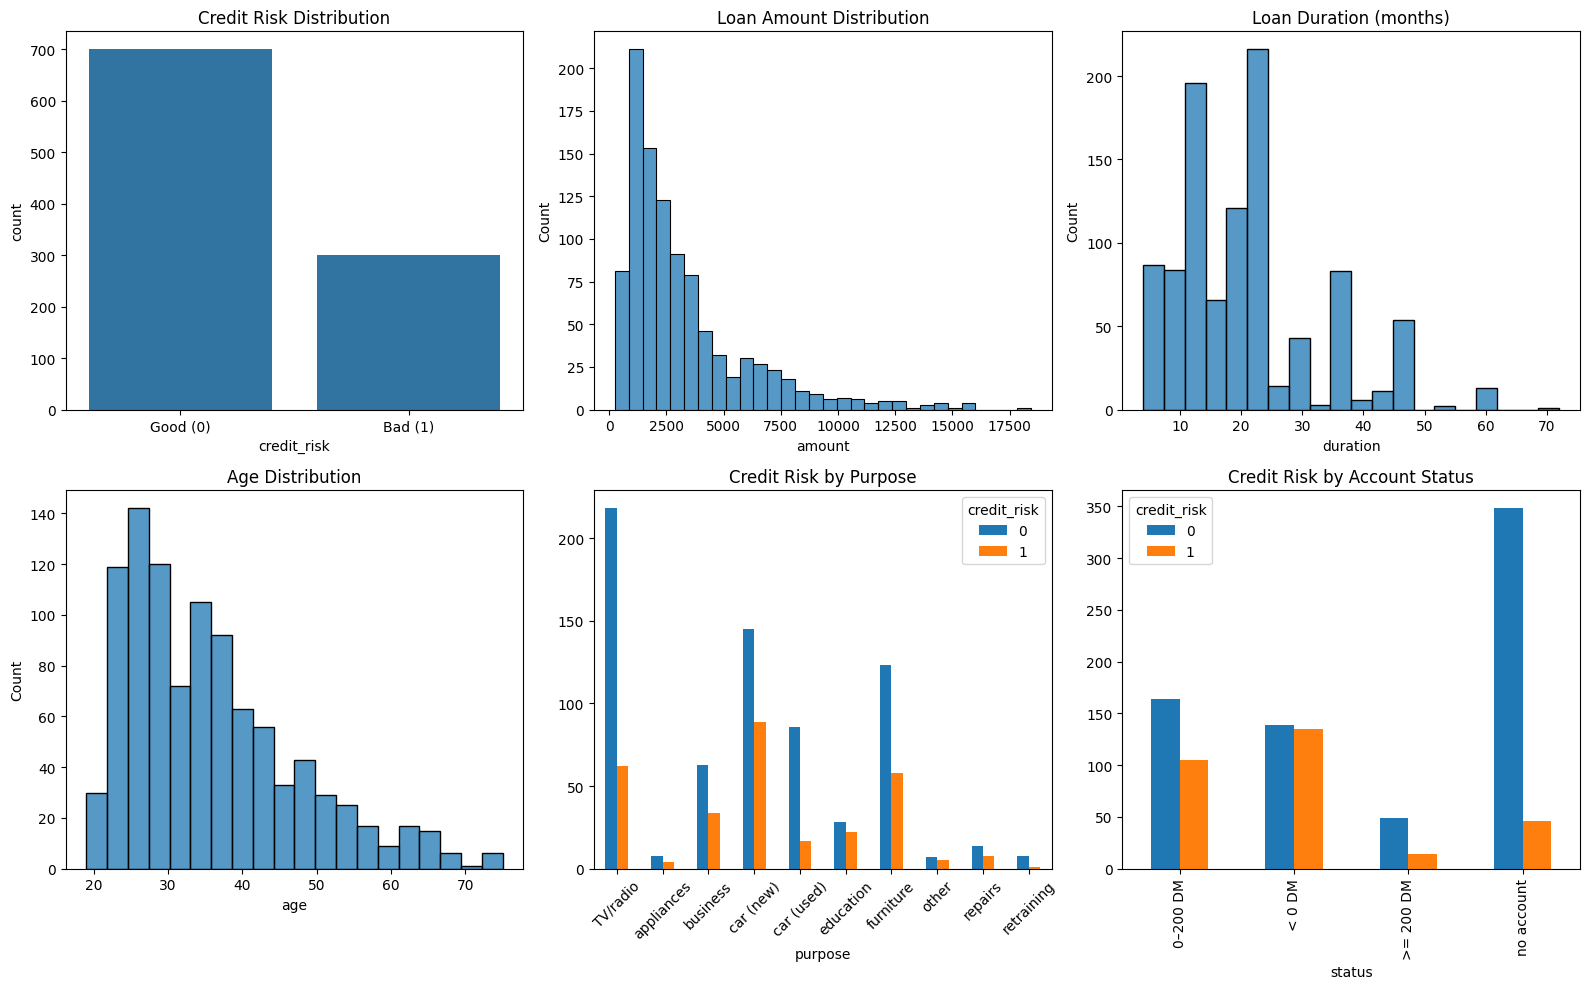

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Target distribution
sns.countplot(x='credit_risk', data=df_decoded, ax=axes[0,0])
axes[0,0].set_title('Credit Risk Distribution')
axes[0,0].set_xticklabels(['Good (0)', 'Bad (1)'])

# 2. Loan amount distribution
sns.histplot(df_decoded['amount'], bins=30, ax=axes[0,1])
axes[0,1].set_title('Loan Amount Distribution')

# 3. Duration distribution
sns.histplot(df_decoded['duration'], bins=20, ax=axes[0,2])
axes[0,2].set_title('Loan Duration (months)')

# 4. Age distribution
sns.histplot(df_decoded['age'], bins=20, ax=axes[1,0])
axes[1,0].set_title('Age Distribution')

# 5. Credit risk by purpose
purpose_counts = df_decoded.groupby(['purpose', 'credit_risk']).size().unstack()
purpose_counts.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Credit Risk by Purpose')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Credit risk by status (checking account)
status_counts = df_decoded.groupby(['status', 'credit_risk']).size().unstack()
status_counts.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Credit Risk by Account Status')

plt.tight_layout()
plt.show()

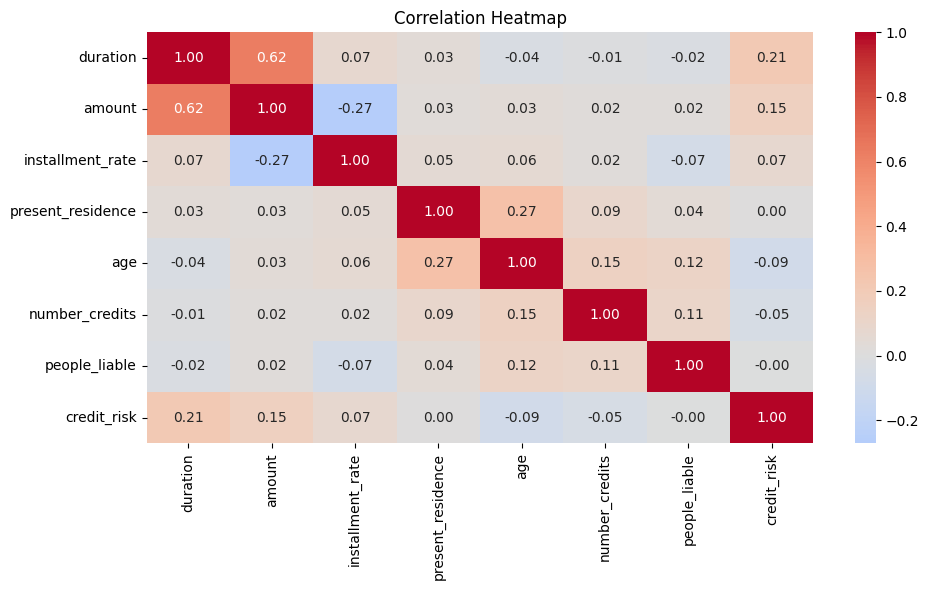

In [7]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_decoded.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import chi2_contingency

cat_cols = ['status', 'credit_history', 'purpose', 'savings', 
            'employment_duration', 'personal_status_sex', 'other_debtors',
            'property', 'other_installment_plans', 'housing', 
            'job', 'telephone', 'foreign_worker']

results = []
for col in cat_cols:
    ct = pd.crosstab(df_decoded[col], df_decoded['credit_risk'])
    chi2, p, dof, _ = chi2_contingency(ct)
    results.append({'feature': col, 'chi2': round(chi2, 2), 'p_value': round(p, 4)})

chi_df = pd.DataFrame(results).sort_values('chi2', ascending=False)
print(chi_df.to_string(index=False))

                feature   chi2  p_value
                 status 123.72   0.0000
         credit_history  61.69   0.0000
                savings  36.10   0.0000
                purpose  33.36   0.0001
               property  23.72   0.0000
    employment_duration  18.37   0.0010
                housing  18.20   0.0001
other_installment_plans  12.84   0.0016
    personal_status_sex   9.61   0.0222
          other_debtors   6.65   0.0361
         foreign_worker   5.82   0.0158
                    job   1.89   0.5966
              telephone   1.17   0.2789
